# Understanding `random_state` in `train_test_split`

This notebook demonstrates **why and how** the `random_state` parameter controls reproducibility when splitting a dataset.

---
### Key idea
Splitting a dataset means randomly shuffling rows and assigning them to train/test groups.  
A **random seed** initialises the random number generator so the same shuffle is produced every time.

| `random_state` | Result |
|---|---|
| `None` (default) | Different split **every run** |
| Any integer, e.g. `42` | **Same split** every run |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split

# Reproducible toy dataset: 20 students with an exam score
np.random.seed(0)
N = 20
student_ids = np.arange(1, N + 1)
scores      = np.random.randint(50, 100, size=N)

df = pd.DataFrame({'student_id': student_ids, 'score': scores})
print(df.T)

            0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  \
student_id   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16   
score       94  97  50  53  53  89  59  69  71  86  73  56  74  74  62  51   

            16  17  18  19  
student_id  17  18  19  20  
score       88  89  73  96  


---
## Part 1 — No seed: a different split every run

Run the cell below multiple times and watch how the training set (blue) and test set (orange) change each time.

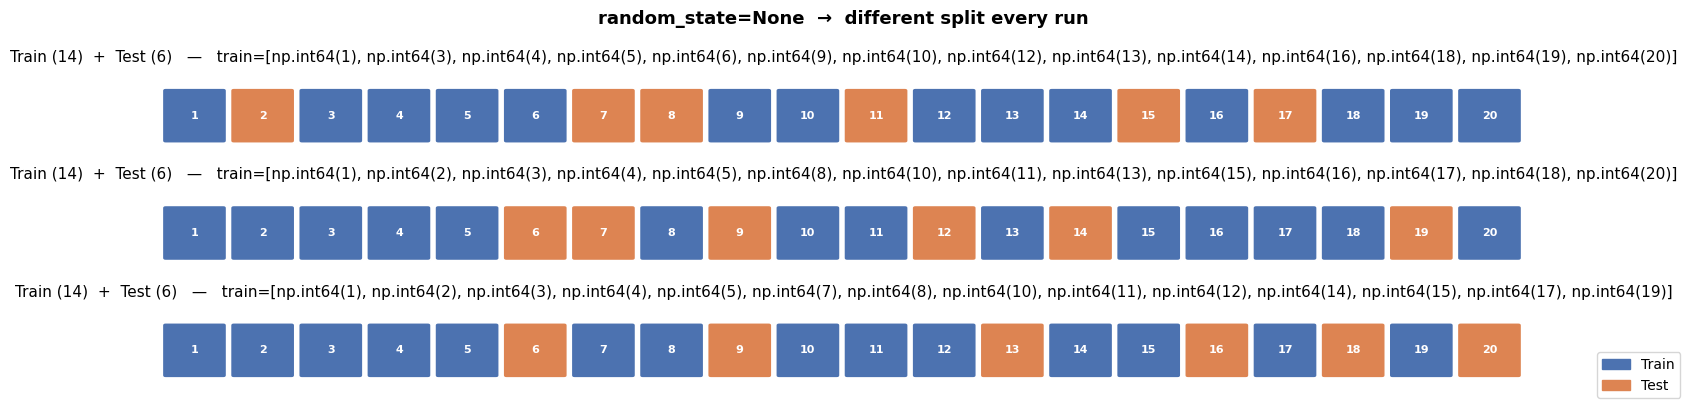

In [2]:
def plot_split(train_ids, test_ids, title, ax):
    """Draw a row of coloured squares — one per student."""
    colors = ['#4C72B0' if sid in set(train_ids) else '#DD8452'
              for sid in student_ids]
    for i, (sid, c) in enumerate(zip(student_ids, colors)):
        ax.add_patch(mpatches.FancyBboxPatch(
            (i, 0), 0.85, 0.85,
            boxstyle='round,pad=0.05',
            facecolor=c, edgecolor='white', linewidth=1.5))
        ax.text(i + 0.425, 0.425, str(sid),
                ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.set_xlim(-0.1, N)
    ax.set_ylim(-0.2, 1.2)
    ax.set_title(title, fontsize=11, pad=6)
    ax.axis('off')

# --- run split with NO seed three times ---
fig, axes = plt.subplots(3, 1, figsize=(14, 4))
fig.suptitle('random_state=None  →  different split every run', fontsize=13, fontweight='bold')

for ax in axes:
    X_tr, X_te = train_test_split(student_ids, test_size=0.3, random_state=None)
    plot_split(X_tr, X_te,
               f'Train ({len(X_tr)})  +  Test ({len(X_te)})   —   '  
               f'train={sorted(X_tr)}', ax)

train_patch = mpatches.Patch(color='#4C72B0', label='Train')
test_patch  = mpatches.Patch(color='#DD8452', label='Test')
fig.legend(handles=[train_patch, test_patch], loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

---
## Part 2 — Fixed seed: the same split every run

Using `random_state=42` freezes the shuffle. No matter how many times you run this cell, the colours never change.

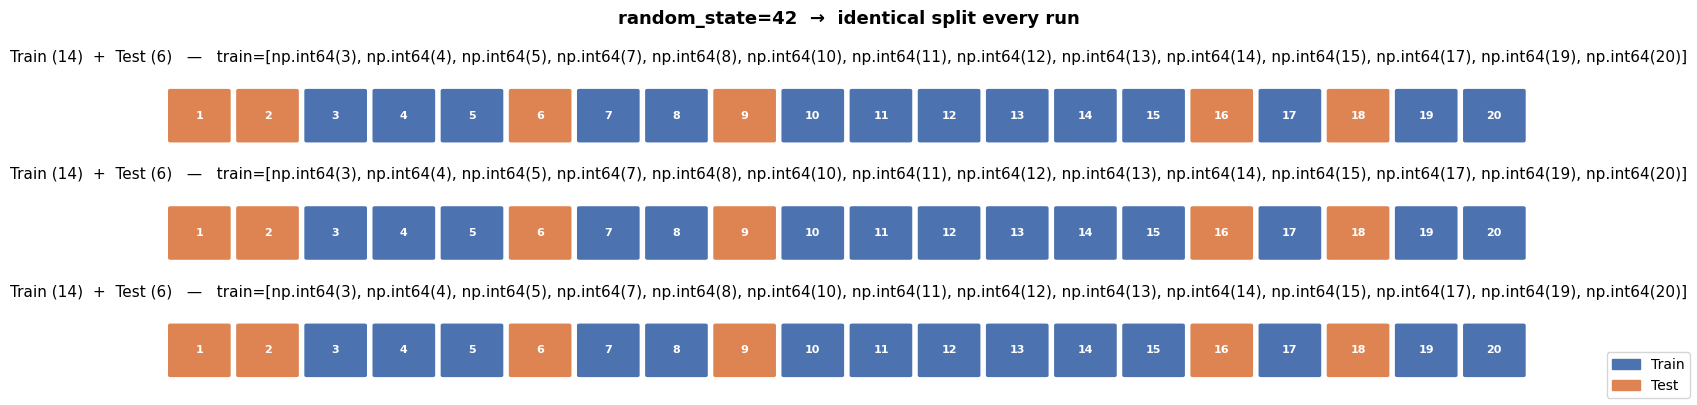

Are all three rows identical?  YES — the seed locks the shuffle.


In [3]:
SEED = 42

fig, axes = plt.subplots(3, 1, figsize=(14, 4))
fig.suptitle(f'random_state={SEED}  →  identical split every run', fontsize=13, fontweight='bold')

for ax in axes:
    X_tr, X_te = train_test_split(student_ids, test_size=0.3, random_state=SEED)
    plot_split(X_tr, X_te,
               f'Train ({len(X_tr)})  +  Test ({len(X_te)})   —   '
               f'train={sorted(X_tr)}', ax)

train_patch = mpatches.Patch(color='#4C72B0', label='Train')
test_patch  = mpatches.Patch(color='#DD8452', label='Test')
fig.legend(handles=[train_patch, test_patch], loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print('Are all three rows identical?  YES — the seed locks the shuffle.')

---
## Part 3 — Different seeds produce different (but each reproducible) splits

Every integer is a valid seed. Each one produces a unique-but-stable shuffle.

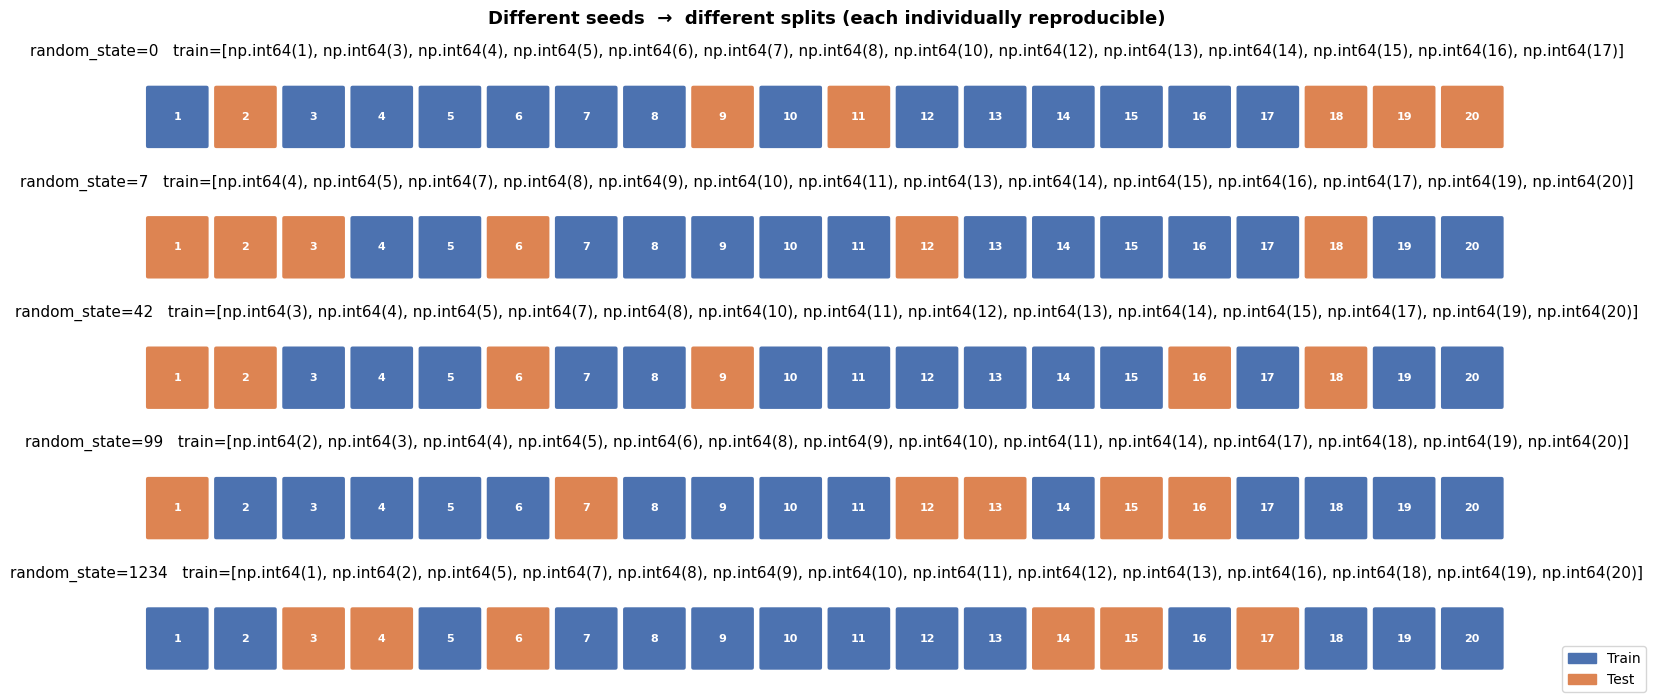

In [4]:
seeds = [0, 7, 42, 99, 1234]

fig, axes = plt.subplots(len(seeds), 1, figsize=(14, 7))
fig.suptitle('Different seeds  →  different splits (each individually reproducible)',
             fontsize=13, fontweight='bold')

for seed, ax in zip(seeds, axes):
    X_tr, X_te = train_test_split(student_ids, test_size=0.3, random_state=seed)
    plot_split(X_tr, X_te, f'random_state={seed}   train={sorted(X_tr)}', ax)

train_patch = mpatches.Patch(color='#4C72B0', label='Train')
test_patch  = mpatches.Patch(color='#DD8452', label='Test')
fig.legend(handles=[train_patch, test_patch], loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

---
## Part 4 — How does the score distribution change with the seed?

A bad split can accidentally put all the high-scorers in one set.  
Below we compare the **mean score** across the train/test sets for many seeds.

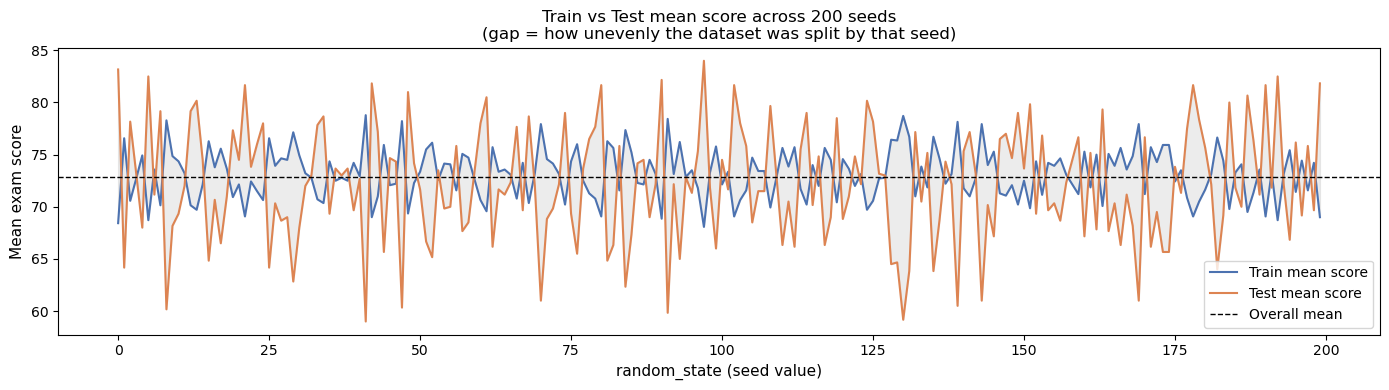

Most   balanced split → seed 94
Least  balanced split → seed 41  (avoid cherry-picking this!)


In [5]:
results = []
test_seeds = range(200)

for s in test_seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        df['student_id'], df['score'], test_size=0.3, random_state=s)
    results.append({'seed': s,
                    'train_mean': y_tr.mean(),
                    'test_mean':  y_te.mean()})

res = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(res['seed'], res['train_mean'], color='#4C72B0', label='Train mean score', linewidth=1.5)
ax.plot(res['seed'], res['test_mean'],  color='#DD8452', label='Test mean score',  linewidth=1.5)
ax.axhline(df['score'].mean(), color='black', linestyle='--', linewidth=1, label='Overall mean')
ax.fill_between(res['seed'], res['train_mean'], res['test_mean'],
                alpha=0.15, color='grey')
ax.set_xlabel('random_state (seed value)', fontsize=11)
ax.set_ylabel('Mean exam score', fontsize=11)
ax.set_title('Train vs Test mean score across 200 seeds\n'
             '(gap = how unevenly the dataset was split by that seed)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

worst_seed = int(res.assign(gap=lambda d: (d.train_mean - d.test_mean).abs())
                   .nlargest(1, 'gap')['seed'].iloc[0])
best_seed  = int(res.assign(gap=lambda d: (d.train_mean - d.test_mean).abs())
                   .nsmallest(1, 'gap')['seed'].iloc[0])
print(f'Most   balanced split → seed {best_seed}')
print(f'Least  balanced split → seed {worst_seed}  (avoid cherry-picking this!)')

---
## Summary

| Question | Answer |
|---|---|
| What does `random_state` do? | Seeds the random number generator that shuffles the data before splitting |
| Why use it? | **Reproducibility** — you and your collaborators get identical train/test sets |
| Does the number matter? | No — any integer works. Convention: use `42`, `0`, or `1` |
| What happens with `None`? | A fresh random seed is drawn from the OS each run → different split every time |
| Should I cherry-pick a seed? | **No.** Pick one seed before you start and never change it — otherwise you're overfitting to the test set |

